In [2]:
#CIA3 - Continuation Of CIA2 (Paper Moisture Test)
#A.Deepak (2460601)
#16-02-2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('paper_moisture_control.csv')
# 2. Timestamp Alignment
time_cols = ['timestamp', 'cycle_start', 'cycle_end']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])
# 3. Data Cleansing (Create df_clean)
# Remove duplicates
df_clean = df.drop_duplicates().copy()
# Fill missing moisture values (Interpolation)
df_clean['moisture_pct'] = df_clean['moisture_pct'].ffill().interpolate(method='linear')
# Handle missing values in other columns (Drop rows where essential data is missing for simplicity)
df_clean.dropna(subset=['paper_grade', 'machine_id', 'temperature_C', 'humidity_pct'], inplace=True)
print(df_clean.head())

            timestamp machine_id   batch_id paper_grade  moisture_pct  \
0 2025-09-01 07:00:00       M004  BATCH_001      coated      6.229510   
1 2025-09-01 07:10:00       M004  BATCH_001      coated      6.525639   
2 2025-09-01 07:20:00       M004  BATCH_001      coated      6.528640   
3 2025-09-01 07:30:00       M004  BATCH_001      coated      6.439983   
4 2025-09-01 07:40:00       M004  BATCH_001      coated      7.116764   

   temperature_C  humidity_pct         cycle_start           cycle_end  \
0      28.048834     56.041926 2025-09-01 07:00:00 2025-09-01 09:00:00   
1      24.146738     54.039701 2025-09-01 07:00:00 2025-09-01 09:00:00   
2      22.919657     54.670740 2025-09-01 07:00:00 2025-09-01 09:00:00   
3      29.414033     33.000346 2025-09-01 07:00:00 2025-09-01 09:00:00   
4      23.824238     45.115315 2025-09-01 07:00:00 2025-09-01 09:00:00   

   deviation_flag  
0               0  
1               0  
2               0  
3               0  
4               

In [3]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

#We have completed the first 3 steps. now the rest few steps are to be completed. 

#4.Feature Engineering and Encoding

# Encode 'paper_grade' and 'machine_id'
le = LabelEncoder()
df_clean['paper_grade_enc'] = le.fit_transform(df_clean['paper_grade'])
df_clean['machine_id_enc'] = le.fit_transform(df_clean['machine_id'])

# Check the new columns
print(df_clean[['paper_grade', 'paper_grade_enc', 'machine_id', 'machine_id_enc']].head())

# Normalization
min_max_scaler = MinMaxScaler()
df_clean['moisture_minmax'] = min_max_scaler.fit_transform(df_clean[['moisture_pct']])
std_scaler = StandardScaler()
df_clean['moisture_zscore'] = std_scaler.fit_transform(df_clean[['moisture_pct']])

  paper_grade  paper_grade_enc machine_id  machine_id_enc
0      coated                0       M004               3
1      coated                0       M004               3
2      coated                0       M004               3
3      coated                0       M004               3
4      coated                0       M004               3


In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#4.1. Min-Max Scaling (Values between 0 and 1)
min_max_scaler = MinMaxScaler()
df_clean['moisture_minmax'] = min_max_scaler.fit_transform(df_clean[['moisture_pct']])

#4.2. Z-Score Scaling (Standard Normalization)
std_scaler = StandardScaler()
df_clean['moisture_zscore'] = std_scaler.fit_transform(df_clean[['moisture_pct']])
df_clean[['moisture_pct', 'moisture_minmax', 'moisture_zscore']].head()

,moisture_pct,moisture_minmax,moisture_zscore
0,6.229510,0.365153,-0.529272
1,6.525639,0.433927,0.003753
2,6.528640,0.434624,0.009155
3,6.439983,0.414034,-0.150426
4,7.116764,0.571212,1.067766


In [5]:
from sklearn.decomposition import PCA

#5. Dimensionality Reduction

# Select features for PCA
features = ['moisture_pct', 'temperature_C', 'humidity_pct']
x = df_clean[features]

# We must scale the data before PCA
x_scaled = StandardScaler().fit_transform(x)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)

# Create a simple DataFrame for results
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
pca_df.head()

Explained Variance Ratio: [0.34200119 0.33581724]


,PC1,PC2
0,0.625723,0.470008
1,-0.396366,0.799987
2,-0.847792,1.066519
3,1.716891,-3.602147
4,0.348700,-0.341943


In [6]:
from sklearn.decomposition import FactorAnalysis

#5.1 Apply Factor Analysis
fa = FactorAnalysis(n_components=2, rotation="varimax")
fa_components = fa.fit_transform(x_scaled)
print("Factor Analysis Run Successfully")

Factor Analysis Run Successfully


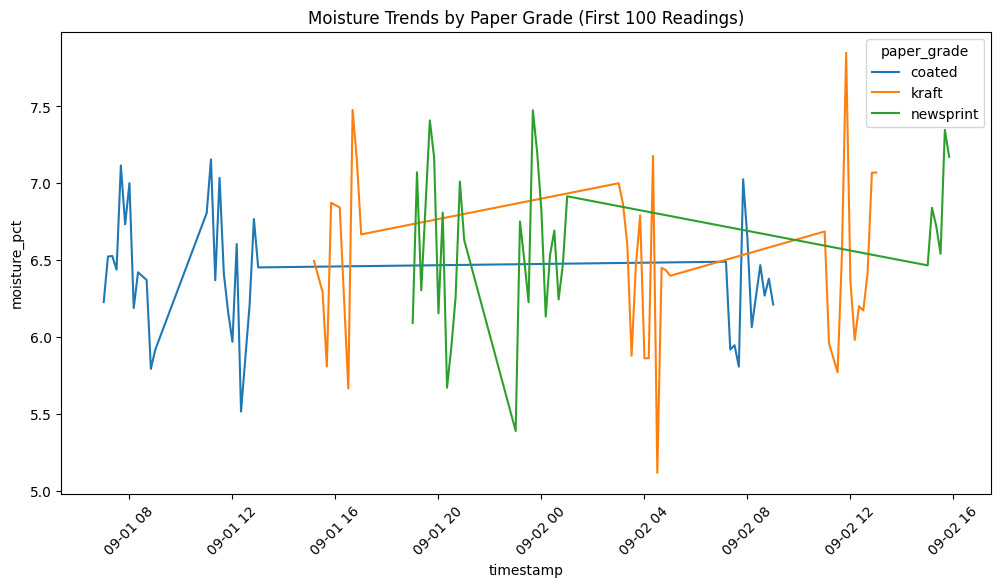

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#6. Visualization and Reporting

#6.1 Line Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean.iloc[:100], x='timestamp', y='moisture_pct', hue='paper_grade')
plt.title('Moisture Trends by Paper Grade (First 100 Readings)')
plt.xticks(rotation=45)
plt.show()

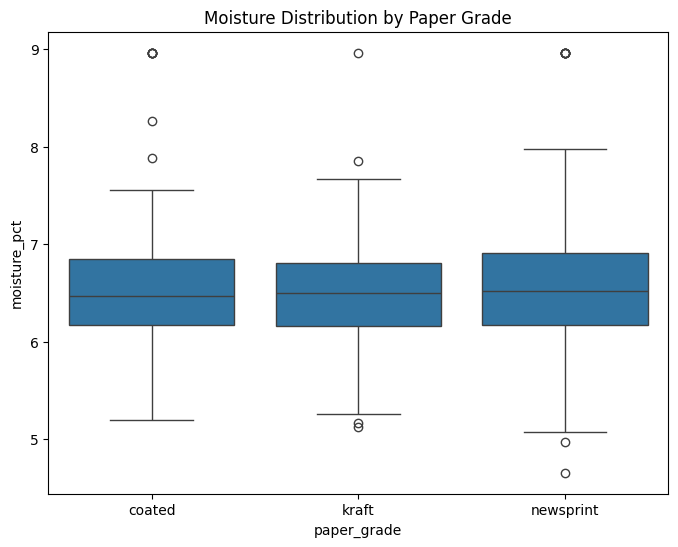

In [8]:
#6.2 Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='paper_grade', y='moisture_pct', data=df_clean)
plt.title('Moisture Distribution by Paper Grade')
plt.show()

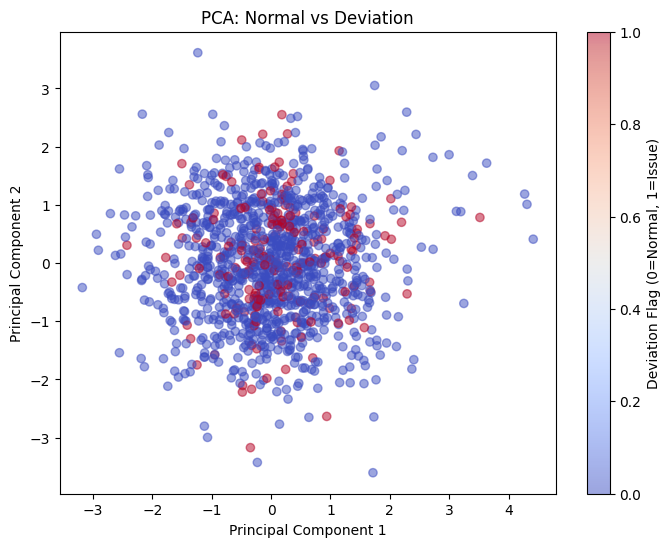

In [9]:
#6.3 PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df_clean['deviation_flag'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Normal vs Deviation')
plt.colorbar(label='Deviation Flag (0=Normal, 1=Issue)')
plt.show()

In [10]:
#7. Data Integration and Export

df_clean.to_csv('final_paper_moisture_cleaned.csv', index=False)
print("CSV file saved successfully.")

CSV file saved successfully.


In [11]:
import sqlite3

#7.1 Data Integration
conn = sqlite3.connect('paper_project.db')
# Save dataframe to SQL table
df_clean.to_sql('moisture_data', conn, if_exists='replace', index=False)
# Close connection
conn.close()
print("Data exported to SQLite database.")

Data exported to SQLite database.
